In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
!pip install einops

if os.path.isdir('Restormer'):
  !rm -r Restormer

# Clone Restormer
!git clone https://github.com/swz30/Restormer.git
%cd Restormer

Cloning into 'Restormer'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 312 (delta 78), reused 76 (delta 76), pack-reused 189 (from 1)
Receiving objects: 100% (312/312), 1.55 MiB | 4.10 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/Restormer


In [ ]:
%cd /content/Restormer

# Cài các dependency cơ bản
!pip install torch torchvision einops timm numpy opencv-python scikit-image matplotlib tqdm

!pip install lmdb
# Thêm /content/Restormer vào sys.path
import sys
sys.path.insert(0, '/content/Restormer')

# Kiểm tra import
try:
    import basicsr
    print("✅ basicsr imported successfully")
except ImportError:
    print("❌ basicsr not found, trying alternative...")

/content/Restormer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 13.1 MB/s eta 0:00:00
✅ basicsr imported successfully


In [ ]:
# Giải nén file data.rar
!unrar x /content/drive/MyDrive/data.rar /content/

# Nếu file là .zip thì dùng:
# !unzip /content/drive/MyDrive/data.zip -d /content/

# Kiểm tra đã giải nén thành công
!ls -la /content/data/

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Extracting  /content/data/degraded/missing/345/g06-037n.jpg               70%  OK 
Extracting  /content/data/degraded/occlusion/345/g06-037n.jpg             70%  OK 
Extracting  /content/data/degraded/noise/345/g06-037n.jpg                 70%  OK 
Extracting  /content/data/degraded/blur/346/g06-037o.jpg                  70%  OK 
Extracting  /content/data/degraded/broken/346/g06-037o.jpg                70%  OK 
Extracting  /content/data/degraded/missing/346/g06-037o.jpg               70%  OK 
Extracting  /content/data/degraded/occlusion/346/g06-037o.jpg             70%  OK 
Extracting  /content/data/degraded/noise/346/g06-037o.jpg                 70%  OK 
Extracting  /content/data/degraded/blur/347/g06-037p.jpg                  70%  OK 
Extracting  /content/data/degraded/broken/347/g06-037p.jpg                70%  OK 
Extracting  /content/da

In [ ]:
task = 'Real_Denoising'
# task = 'Single_Image_Defocus_Deblurring'
# task = 'Motion_Deblurring'
# task = 'Deraining'

# Download the pre-trained models
if task == 'Real_Denoising':
  !wget https://github.com/swz30/Restormer/releases/download/v1.0/real_denoising.pth -P Denoising/pretrained_models
if task == 'Single_Image_Defocus_Deblurring':
  !wget https://github.com/swz30/Restormer/releases/download/v1.0/single_image_defocus_deblurring.pth -P Defocus_Deblurring/pretrained_models
if task == 'Motion_Deblurring':
  !wget https://github.com/swz30/Restormer/releases/download/v1.0/motion_deblurring.pth -P Motion_Deblurring/pretrained_models
if task == 'Deraining':
  !wget https://github.com/swz30/Restormer/releases/download/v1.0/deraining.pth -P Deraining/pretrained_models


--2026-09-16 08:16:24--  https://github.com/swz30/Restormer/releases/download/v1.0/real_denoising.pth
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/418793252/577ea2a7-8cf3-44b2-900d-5368f402de29?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-16T08%3A52%3A48Z&rscd=attachment%3B+filename%3Dreal_denoising.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-16T07%3A52%3A40Z&ske=2026-09-16T08%3A52%3A48Z&sks=b&skv=2018-11-09&sig=JzDcv0uFZ4Ax4pi2lNOnXvOgC6s81aF2T0dKNPmMc9M%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTU0ODM4NCwibmJmIjoxNzg5NTQ2NTg0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG

In [ ]:
import os
import shutil
from tqdm import tqdm

# ==================== CẤU HÌNH ====================
DATA_ROOT = '/content/data'
CLEAN_ROOT = os.path.join(DATA_ROOT, 'clean')
DEGRADED_ROOT = os.path.join(DATA_ROOT, 'degraded')
SPLIT_ROOT = os.path.join(DATA_ROOT, 'splits')

# ✅ XỬ LÝ TẤT CẢ 5 LOẠI
DEG_TYPES = ['noise', 'blur', 'broken', 'missing', 'occlusion']
# ====================================================

def normalize(p):
    """Chuẩn hóa dấu \ thành / và bỏ khoảng trắng"""
    return p.replace('\\', '/').strip()

def find_file(base_path, rel_no_ext):
    """Tìm file với bất kỳ đuôi nào"""
    for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff',
                '.PNG', '.JPG', '.JPEG', '.BMP']:
        p = os.path.join(base_path, rel_no_ext + ext)
        if os.path.exists(p):
            return p
    return None

def process_split(split_name):
    split_file = os.path.join(SPLIT_ROOT, f'{split_name}.txt')
    if not os.path.exists(split_file):
        print(f"⚠️ Không có {split_file}")
        return

    with open(split_file) as f:
        rel_paths = [normalize(l) for l in f if l.strip()]

    print(f"\n📂 Xử lý {split_name}: {len(rel_paths)} entries")

    # Tạo thư mục đích
    out_clean = os.path.join(DATA_ROOT, split_name, 'clean')
    os.makedirs(out_clean, exist_ok=True)
    out_degs = {}
    for deg in DEG_TYPES:
        out_deg = os.path.join(DATA_ROOT, split_name, 'degraded', deg)
        os.makedirs(out_deg, exist_ok=True)
        out_degs[deg] = out_deg

    n_clean = 0
    n_deg = {deg: 0 for deg in DEG_TYPES}
    missing_clean = 0
    missing_deg = {deg: 0 for deg in DEG_TYPES}

    for rel in tqdm(rel_paths, desc=f"Copy {split_name}"):
        # rel = "021/a02-000.png"
        rel_no_ext = os.path.splitext(rel)[0]      # "021/a02-000"
        flat_base = rel_no_ext.replace('/', '_')   # "021_a02-000"

        # --- Copy clean ---
        src_clean = find_file(CLEAN_ROOT, rel_no_ext)
        if src_clean is None:
            missing_clean += 1
            continue
        ext = os.path.splitext(src_clean)[1]
        dst_clean = os.path.join(out_clean, flat_base + ext)
        shutil.copy2(src_clean, dst_clean)
        n_clean += 1

        # --- Copy TẤT CẢ degraded ---
        for deg in DEG_TYPES:
            src_deg = find_file(os.path.join(DEGRADED_ROOT, deg), rel_no_ext)
            if src_deg is None:
                missing_deg[deg] += 1
                continue
            d_ext = os.path.splitext(src_deg)[1]
            dst_deg = os.path.join(out_degs[deg], flat_base + d_ext)
            shutil.copy2(src_deg, dst_deg)
            n_deg[deg] += 1

    # In kết quả
    print(f"✅ {split_name}: clean={n_clean} (missing {missing_clean})")
    for deg in DEG_TYPES:
        print(f"   {deg}: {n_deg[deg]} (missing {missing_deg[deg]})")

# Chạy cho cả 3 tập
for s in ['train', 'val', 'test']:
    process_split(s)

# ==================== KIỂM TRA ====================
print("\n" + "="*60)
print("📊 KIỂM TRA SAU KHI FLATTEN")
print("="*60)

for split in ['train', 'val', 'test']:
    print(f"\n📂 {split}:")
    for sub in ['clean'] + [f'degraded/{d}' for d in DEG_TYPES]:
        path = os.path.join(DATA_ROOT, split, sub)
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
            print(f"  {sub}: {len(files)} files")
        else:
            print(f"  {sub}: ❌ KHÔNG TỒN TẠI")

<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_758/2608419840.py:16: SyntaxWarning: invalid escape sequence '\ '
  """Chuẩn hóa dấu \ thành / và bỏ khoảng trắng"""



📂 Xử lý train: 1077 entries


Copy train: 100%|██████████| 1077/1077 [00:02<00:00, 509.68it/s]


✅ train: clean=1077 (missing 0)
   noise: 1077 (missing 0)
   blur: 1077 (missing 0)
   broken: 1077 (missing 0)
   missing: 1077 (missing 0)
   occlusion: 1077 (missing 0)

📂 Xử lý val: 231 entries


Copy val: 100%|██████████| 231/231 [00:02<00:00, 97.22it/s]


✅ val: clean=231 (missing 0)
   noise: 231 (missing 0)
   blur: 231 (missing 0)
   broken: 231 (missing 0)
   missing: 231 (missing 0)
   occlusion: 231 (missing 0)

📂 Xử lý test: 231 entries


Copy test: 100%|██████████| 231/231 [00:00<00:00, 638.07it/s]

✅ test: clean=231 (missing 0)
   noise: 231 (missing 0)
   blur: 231 (missing 0)
   broken: 231 (missing 0)
   missing: 231 (missing 0)
   occlusion: 231 (missing 0)

📊 KIỂM TRA SAU KHI FLATTEN

📂 train:
  clean: 1077 files
  degraded/noise: 1077 files
  degraded/blur: 1077 files
  degraded/broken: 1077 files
  degraded/missing: 1077 files
  degraded/occlusion: 1077 files

📂 val:
  clean: 231 files
  degraded/noise: 231 files
  degraded/blur: 231 files
  degraded/broken: 231 files
  degraded/missing: 231 files
  degraded/occlusion: 231 files

📂 test:
  clean: 231 files
  degraded/noise: 231 files
  degraded/blur: 231 files
  degraded/broken: 231 files
  degraded/missing: 231 files
  degraded/occlusion: 231 files


In [ ]:
# ==================== CELL 1: DETECT + COPY CHECKPOINT ====================
import os, glob, shutil, re

# ══════ CHỈ SỬA 2 DÒNG NÀY ══════
STEP_NAME = 'broken'
MODE      = 'new'          # 'new' | 'resume'
# ═════════════════════════════════

STEP_ORDER = ['noise', 'blur', 'broken', 'missing', 'occlusion', 'final']

PROJECT_ROOT = '/content/drive/MyDrive/Document_Restoration_Project'
CKPT_ROOT    = f'{PROJECT_ROOT}/checkpoints'
RESTORMER    = '/content/Restormer'

STEP_IDX    = STEP_ORDER.index(STEP_NAME)
STEP_NUMBER = STEP_IDX + 1
ROOT_NAME   = f'Document_Restoration_{STEP_NAME.capitalize()}'
RUNTIME_EXP = f'{RESTORMER}/experiments/{ROOT_NAME}'   # ← Cell 2 trỏ tới đây

CURRENT_DIR = f'{CKPT_ROOT}/{STEP_NUMBER}_{STEP_NAME}'
PREV_NAME   = STEP_ORDER[STEP_IDX-1] if STEP_IDX > 0 else None
PREV_DIR    = f'{CKPT_ROOT}/{STEP_IDX}_{PREV_NAME}' if PREV_NAME else None


def scan_ckpt(d):
    if not d or not os.path.isdir(d):
        return []
    pths = glob.glob(f'{d}/net_g_*.pth') + glob.glob(f'{d}/models/net_g_*.pth')
    out = []
    for p in pths:
        m = re.search(r'net_g_(\d+)', os.path.basename(p))
        if not m:
            continue
        it = int(m.group(1))
        st = None
        for cand in [f'{d}/{it}.state', f'{d}/training_states/{it}.state']:
            if os.path.exists(cand):
                st = cand
                break
        out.append((it, p, st))
    out.sort(key=lambda x: x[0])
    return out


# ─── Chọn nguồn theo MODE ───
if MODE == 'new':
    SRC_DIR = PREV_DIR if STEP_IDX > 0 else f'{CKPT_ROOT}/0_pretrained'
elif MODE == 'resume':
    SRC_DIR = CURRENT_DIR
else:
    raise ValueError(f"MODE phải là 'new' hoặc 'resume'")

ckpt_list = scan_ckpt(SRC_DIR)
if not ckpt_list:
    raise FileNotFoundError(f"❌ Không có checkpoint trong {SRC_DIR}")

it, pth_src, state_src = ckpt_list[-1]

print("="*70)
print(f"🎯 BƯỚC {STEP_NUMBER}: {STEP_NAME.upper()}")
print(f"📌 MODE : {MODE}")
print(f"📌 ITER : {it}")
print(f"📂 Đích : {RUNTIME_EXP}")
print("="*70)


# ─── Copy vào đúng chỗ Cell 2 trỏ tới ───
os.makedirs(f'{RUNTIME_EXP}/models', exist_ok=True)
os.makedirs(f'{RUNTIME_EXP}/training_states', exist_ok=True)

# .pth
PRETRAIN_PATH = f'{RUNTIME_EXP}/models/net_g_{it}.pth'
shutil.copy2(pth_src, PRETRAIN_PATH)
print(f"✅ {PRETRAIN_PATH}")

# .state (chỉ resume)
RESUME_PATH = None
if MODE == 'resume' and state_src:
    RESUME_PATH = f'{RUNTIME_EXP}/training_states/{it}.state'
    shutil.copy2(state_src, RESUME_PATH)
    print(f"✅ {RESUME_PATH}")
else:
    print(f"⏭️  Không copy .state")

print("\n▶️ Chạy Cell 2 để sinh YAML")

FileNotFoundError: ❌ Không có checkpoint trong /content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur

In [ ]:
import os, re, shutil, glob

BLUR_DIR = '/content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur'

# ══════ Xem hiện trạng ══════
print("📂 Trước:")
for f in sorted(os.listdir(BLUR_DIR)):
    print(f"  {f}")

# ══════ Rename .pth: bỏ suffix _blur/_noise/_broken/... ══════
for p in glob.glob(f'{BLUR_DIR}/net_g_*.pth'):
    m = re.search(r'net_g_(\d+)', os.path.basename(p))
    if not m:
        continue
    it = m.group(1)
    dst = f'{BLUR_DIR}/net_g_{it}.pth'
    if os.path.abspath(p) != os.path.abspath(dst):
        if os.path.exists(dst):
            os.remove(dst)
        shutil.move(p, dst)
        print(f"  ✅ {os.path.basename(p)}  →  net_g_{it}.pth")

# ══════ Rename .state: bỏ suffix ══════
for s in glob.glob(f'{BLUR_DIR}/*.state'):
    m = re.search(r'^(\d+)', os.path.basename(s))
    if not m:
        continue
    it = m.group(1)
    dst = f'{BLUR_DIR}/{it}.state'
    if os.path.abspath(s) != os.path.abspath(dst):
        if os.path.exists(dst):
            os.remove(dst)
        shutil.move(s, dst)
        print(f"  ✅ {os.path.basename(s)}  →  {it}.state")

# ══════ Xem kết quả ══════
print("\n📂 Sau:")
for f in sorted(os.listdir(BLUR_DIR)):
    print(f"  {f}")

📂 Trước:
  30000.state
  50000.state
  my_config_blur.yml
  net_g_30000.pth
  net_g_50000.pth

📂 Sau:
  30000.state
  50000.state
  my_config_blur.yml
  net_g_30000.pth
  net_g_50000.pth


In [ ]:
# ==================== CELL 1B: TẠO DATASET REPLAY ====================
#
import os, shutil, random, glob

STEP_ORDER = ['noise', 'blur', 'broken', 'missing', 'occlusion', 'final']
STEP_IDX   = STEP_ORDER.index(STEP_NAME)
STEP_NUMBER = STEP_IDX + 1

REPLAY_TYPES = STEP_ORDER[:STEP_IDX]
NEW_TYPE     = STEP_NAME
AUTO_RATIOS  = {0: 1.0, 1: 0.7, 2: 0.5, 3: 0.4, 4: 0.3, 5: 0.2}
NEW_RATIO    = AUTO_RATIOS.get(STEP_IDX, 0.3)

DATA_ORIGIN    = '/content/data'
OUTPUT_ROOT    = '/content/data_replay'
OUTPUT_DATASET = f'{OUTPUT_ROOT}/{STEP_NAME}'

print("="*70)
print(f"📦 DATASET REPLAY — BƯỚC {STEP_NUMBER}: {STEP_NAME.upper()}")
print("="*70)
print(f"  NEW_TYPE     : {NEW_TYPE}")
print(f"  REPLAY_TYPES : {REPLAY_TYPES if REPLAY_TYPES else '(bước đầu)'}")
print(f"  NEW_RATIO    : {NEW_RATIO}")
print(f"  Output       : {OUTPUT_DATASET}")


# ══════ HARD LINK (không tốn dung lượng) ══════
def link_or_copy(src, dst):
    """Tạo hardlink → file 'mới' trỏ cùng inode với file gốc.
    Không tốn dung lượng, không thực sự 'ghi ra' bản sao."""
    if os.path.exists(dst):
        return
    try:
        os.link(src, dst)          # hardlink (cùng partition)
    except (OSError, NotImplementedError):
        shutil.copy2(src, dst)     # fallback nếu khác partition


def find_clean(clean_dir, base):
    for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
        p = f'{clean_dir}/{base}{ext}'
        if os.path.exists(p):
            return p
    return None


def make_pair(src_deg_file, base, prefix, clean_src, deg_dst, clean_dst):
    fname = os.path.basename(src_deg_file)
    link_or_copy(src_deg_file, f'{deg_dst}/{prefix}_{fname}')
    clean_file = find_clean(clean_src, base)
    if clean_file:
        clean_ext = os.path.splitext(clean_file)[1]
        link_or_copy(clean_file, f'{clean_dst}/{prefix}_{base}{clean_ext}')
        return True
    return False


# ── Xóa output cũ ──
if os.path.exists(OUTPUT_DATASET):
    shutil.rmtree(OUTPUT_DATASET)

for split in ['train', 'val']:
    os.makedirs(f'{OUTPUT_DATASET}/{split}/clean', exist_ok=True)
    os.makedirs(f'{OUTPUT_DATASET}/{split}/degraded', exist_ok=True)

random.seed(42)

for split in ['train', 'val']:
    clean_src = f'{DATA_ORIGIN}/{split}/clean'
    clean_dst = f'{OUTPUT_DATASET}/{split}/clean'
    deg_dst   = f'{OUTPUT_DATASET}/{split}/degraded'

    # ════════ 1. NEW_TYPE ════════
    src_new = f'{DATA_ORIGIN}/{split}/degraded/{NEW_TYPE}'
    if not os.path.isdir(src_new):
        raise FileNotFoundError(f"❌ Không có: {src_new}")

    new_files = os.listdir(src_new)
    n_new = 0
    for f in new_files:
        base = os.path.splitext(f)[0]
        if make_pair(f'{src_new}/{f}', base, NEW_TYPE, clean_src, deg_dst, clean_dst):
            n_new += 1

    print(f"\n  [{split}] {NEW_TYPE}: {n_new} cặp")

    # ════════ 2. REPLAY ════════
    if REPLAY_TYPES:
        n_replay_total = int(n_new * (1 - NEW_RATIO) / NEW_RATIO)
        per_type = max(1, n_replay_total // len(REPLAY_TYPES))

        for replay_type in REPLAY_TYPES:
            src_replay = f'{DATA_ORIGIN}/{split}/degraded/{replay_type}'
            if not os.path.isdir(src_replay):
                print(f"    ⚠️ Bỏ qua {replay_type}: không có {src_replay}")
                continue

            files = os.listdir(src_replay)
            selected = random.sample(files, min(per_type, len(files)))

            n_ok = 0
            for f in selected:
                base = os.path.splitext(f)[0]
                if make_pair(f'{src_replay}/{f}', base, replay_type, clean_src, deg_dst, clean_dst):
                    n_ok += 1

            print(f"    ↻ replay {replay_type}: {n_ok} cặp")

# ════════ 3. KIỂM TRA ════════
print("\n" + "="*70)
print("📊 KIỂM TRA KẾT QUẢ")
print("="*70)

ok = True
for split in ['train', 'val']:
    clean_bases = set(os.path.splitext(f)[0] for f in os.listdir(f'{OUTPUT_DATASET}/{split}/clean'))
    deg_bases   = set(os.path.splitext(f)[0] for f in os.listdir(f'{OUTPUT_DATASET}/{split}/degraded'))
    n_clean, n_deg = len(clean_bases), len(deg_bases)
    matched = len(clean_bases & deg_bases)
    status = "✅" if n_clean == n_deg == matched else "❌"
    if status == "❌":
        ok = False
    print(f"  {status} {split}: clean={n_clean}, degraded={n_deg}, khớp={matched}")

print("="*70)
print(f"🎉 SẴN SÀNG: {OUTPUT_DATASET}" if ok else "❌ LỖI")
print("="*70)

📦 DATASET REPLAY — BƯỚC 3: BROKEN
  NEW_TYPE     : broken
  REPLAY_TYPES : ['noise', 'blur']
  NEW_RATIO    : 0.5
  Output       : /content/data_replay/broken

  [train] broken: 1077 cặp
    ↻ replay noise: 538 cặp
    ↻ replay blur: 538 cặp

  [val] broken: 231 cặp
    ↻ replay noise: 115 cặp
    ↻ replay blur: 115 cặp

📊 KIỂM TRA KẾT QUẢ
  ✅ train: clean=2153, degraded=2153, khớp=2153
  ✅ val: clean=461, degraded=461, khớp=461
🎉 SẴN SÀNG: /content/data_replay/broken


In [ ]:
# ==================== CELL 2: SINH YAML ĐỘNG ====================
# Dùng biến từ Cell 1: STEP_NAME, STEP_NUMBER, ROOT_NAME, RUNTIME_EXP,
#                      YAML_PATH, PRETRAIN_PATH, RESUME_PATH

print("="*70)
print(f"📝 SINH YAML — {STEP_NAME.upper()}")
print("="*70)

# ─────────── Config mặc định (step 1-5) ───────────
DATA_ROOT  = f'/content/data_replay/{STEP_NAME}'
TOTAL_ITER = 50000
PERIODS    = '[15000, 35000]'
ETA_MINS   = '[0.0001, 0.000001]'
LR         = '1e-4'
BATCH_SIZE = 2
SAVE_FREQ  = 5000
VAL_FREQ   = 5000
PRINT_FREQ = 100

# ─────────── Override riêng cho step final ───────────
if STEP_NAME == 'final':
    DATA_ROOT  = '/content/data_all'
    TOTAL_ITER = 200000
    PERIODS    = '[50000, 150000]'
    ETA_MINS   = '[0.00005, 0.000001]'
    LR         = '5e-5'
    SAVE_FREQ  = 20000
    VAL_FREQ   = 10000
    PRINT_FREQ = 200

# ─────────── Sinh YAML ───────────
yaml_content = f"""name: {ROOT_NAME}
model_type: ImageCleanModel
num_gpu: 1
manual_seed: 42
scale: 1
dist: false
find_unused_parameters: false

datasets:
  train:
    name: DocumentTrain
    type: Dataset_PairedImage
    dataroot_gt: {DATA_ROOT}/train/clean
    dataroot_lq: {DATA_ROOT}/train/degraded
    filename_tmpl: '{{}}'
    io_backend:
      type: disk
    gt_size: 128
    use_flip: true
    use_rot: true
    geometric_augs: false
    use_shuffle: true
    num_worker_per_gpu: 4
    batch_size_per_gpu: {BATCH_SIZE}
    dataset_enlarge_ratio: 1
    prefetch_mode: ~
    iters: {PERIODS}
    mini_batch_sizes: [{BATCH_SIZE}, {BATCH_SIZE}]
    gt_sizes: [128, 128]

  val:
    name: DocumentVal
    type: Dataset_PairedImage
    dataroot_gt: {DATA_ROOT}/val/clean
    dataroot_lq: {DATA_ROOT}/val/degraded
    filename_tmpl: '{{}}'
    io_backend:
      type: disk
    gt_size: 128
    geometric_augs: false

network_g:
  type: Restormer
  inp_channels: 3
  out_channels: 3
  dim: 32
  num_blocks: [2, 4, 4, 6]
  num_refinement_blocks: 2
  heads: [1, 2, 4, 8]
  ffn_expansion_factor: 2.66
  bias: false
  LayerNorm_type: BiasFree
  dual_pixel_task: false

path:
  pretrain_network_g: {PRETRAIN_PATH}
  resume_state: {RESUME_PATH if RESUME_PATH else '~'}
  strict_load_g: true
  param_key_g: params
  root: {RUNTIME_EXP}

train:
  ema_decay: 0.999
  optim_g:
    type: AdamW
    lr: !!float {LR}
    weight_decay: !!float 1e-4
    betas: [0.9, 0.999]
  scheduler:
    type: CosineAnnealingRestartCyclicLR
    periods: {PERIODS}
    restart_weights: [1, 1]
    eta_mins: {ETA_MINS}
  mixing_augs:
    mixup: false
    mixup_beta: 1.2
    use_identity: false
  total_iter: {TOTAL_ITER}
  warmup_iter: -1
  use_grad_clip: true
  use_amp: true
  pixel_opt:
    type: L1Loss
    loss_weight: 1.0
    reduction: mean

val:
  window_size: 8
  val_freq: !!float {VAL_FREQ}
  save_img: false
  rgb2bgr: true
  use_image: false
  max_minibatch: 1
  metrics:
    psnr:
      type: calculate_psnr
      crop_border: 0
      test_y_channel: false

logger:
  print_freq: {PRINT_FREQ}
  save_checkpoint_freq: !!float {SAVE_FREQ}
  use_tb_logger: true
  wandb:
    project: ~
    resume_id: ~

dist_params:
  backend: nccl
  port: 29500
"""

with open(YAML_PATH, 'w') as f:
    f.write(yaml_content)


# ═══════════════ TÓM TẮT ═══════════════
print(f"\n📄 Đã ghi: {YAML_PATH}")
print(f"   data           : {DATA_ROOT}")
print(f"   total_iter     : {TOTAL_ITER}")
print(f"   lr             : {LR}")
print(f"   periods        : {PERIODS}")

print(f"\n📄 Section 'path:' trong YAML:")
with open(YAML_PATH) as f:
    in_path = False
    for line in f:
        if line.strip().startswith('path:'):
            in_path = True
        elif in_path and line and not line.startswith(' '):
            break
        if in_path:
            print(f"   {line.rstrip()}")

print(f"\n{'='*70}")
print(f"✅ XONG — chạy Cell 3 để train")
print(f"{'='*70}")

📝 SINH YAML — BROKEN

📄 Đã ghi: /content/Restormer/my_config_broken.yml
   data           : /content/data_replay/broken
   total_iter     : 50000
   lr             : 1e-4
   periods        : [15000, 35000]

📄 Section 'path:' trong YAML:
   path:
     pretrain_network_g: /content/Restormer/experiments/Document_Restoration_Broken/models/net_g_50000.pth
     resume_state: ~
     strict_load_g: true
     param_key_g: params
     root: /content/Restormer/experiments/Document_Restoration_Broken

✅ XONG — chạy Cell 3 để train


In [ ]:
# ==================== CELL 3: TRAIN ====================
import os
import sys

RESTORMER_DIR = '/content/Restormer'

CONFIG_FILE = f'{RESTORMER_DIR}/my_config_{STEP_NAME}.yml'

print("="*70)
print(f"🚀 TRAIN: {STEP_NAME.upper()}")
print("="*70)
print(f"📄 Config: {CONFIG_FILE}")
print("="*70 + "\n")

os.chdir(RESTORMER_DIR)
sys.path.insert(0, RESTORMER_DIR)

!PYTHONPATH={RESTORMER_DIR} python -u basicsr/train.py -opt {CONFIG_FILE}

🚀 TRAIN: BROKEN
📄 Config: /content/Restormer/my_config_broken.yml

Disable distributed.
Path already exists. Rename it to /content/Restormer/experiments/Document_Restoration_Broken_archived_20260916_090111
Path already exists. Rename it to tb_logger/Document_Restoration_Broken_archived_20260916_090111
2026-09-16 09:01:11,608 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)
    
Version Information: 
	BasicSR: 1.2.0+10018c6
	PyTorch: 2.11.

In [ ]:
import os
print("📂 Checkpoint blur trên Drive:")
for root, dirs, files in os.walk('/content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur'):
    for f in files:
        if f.endswith(('.pth', '.state')):
            print(f"  {os.path.join(root, f).replace('/content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur', '.')}")

📂 Checkpoint blur trên Drive:
  ./30000.state
  ./net_g_30000.pth
  ./net_g_50000.pth
  ./50000.state


In [ ]:
# ==================== BACKUP CHECKPOINT LÊN DRIVE (FLATTEN, AN TOÀN) ====================
import shutil, os, glob

# ══════ CHỈ SỬA DÒNG NÀY ══════
STEP_NAME = 'blur'
# ═══════════════════════════════

STEP_ORDER = ['noise', 'blur', 'broken', 'missing', 'occlusion', 'final']

RESTORMER_DIR = '/content/Restormer'
PROJECT_ROOT  = '/content/drive/MyDrive/Document_Restoration_Project'

STEP_IDX    = STEP_ORDER.index(STEP_NAME)
STEP_NUMBER = STEP_IDX + 1
ROOT_NAME   = f'Document_Restoration_{STEP_NAME.capitalize()}'
SRC_ROOT    = f'{RESTORMER_DIR}/experiments/{ROOT_NAME}'
DST         = f'{PROJECT_ROOT}/checkpoints/{STEP_NUMBER}_{STEP_NAME}'

print("="*70)
print(f"📦 BACKUP: {STEP_NAME.upper()} (Bước {STEP_NUMBER})")
print("="*70)
print(f"📂 Nguồn: {SRC_ROOT}")
print(f"📂 Đích : {DST}")

# --- Kiểm tra nguồn ---
if not os.path.exists(SRC_ROOT):
    !ls {RESTORMER_DIR}/experiments/
    raise FileNotFoundError(f"Không tìm thấy {SRC_ROOT}")

pth_files = glob.glob(f'{SRC_ROOT}/models/net_g_*.pth')
if not pth_files:
    !ls -la {SRC_ROOT}/models/
    raise FileNotFoundError(f"Không có .pth trong {SRC_ROOT}/models/")


# ✅ Lọc file có iter là số
def get_iter(p):
    name = os.path.basename(p).replace('net_g_', '').replace('.pth', '')
    return int(name) if name.isdigit() else -1

pth_num = [f for f in pth_files if get_iter(f) >= 0]
skipped = [f for f in pth_files if get_iter(f) < 0]

if skipped:
    print(f"⚠️ Bỏ qua:")
    for f in skipped:
        print(f"   • {os.path.basename(f)}")

if not pth_num:
    raise FileNotFoundError(f"Không có .pth dạng số")

latest_iter = max(get_iter(f) for f in pth_num)
print(f"\n📦 Iter mới nhất: {latest_iter}")

# --- Tạo thư mục đích ---
os.makedirs(DST, exist_ok=True)

# --- 1. Copy .pth mới nhất (đổi tên có _step) ---
latest_pth = f'{SRC_ROOT}/models/net_g_{latest_iter}.pth'
dst_pth    = f'{DST}/net_g_{latest_iter}_{STEP_NAME}.pth'    # ← THÊM _STEP_NAME
shutil.copy2(latest_pth, dst_pth)
size = os.path.getsize(dst_pth) / (1024**2)
print(f"   ✅ net_g_{latest_iter}_{STEP_NAME}.pth ({size:.1f} MB)")

# --- 2. Copy .state ---
latest_state = f'{SRC_ROOT}/training_states/{latest_iter}.state'
if os.path.exists(latest_state):
    dst_state = f'{DST}/{latest_iter}_{STEP_NAME}.state'      # ← THÊM _STEP_NAME
    shutil.copy2(latest_state, dst_state)
    size = os.path.getsize(dst_state) / (1024**2)
    print(f"   ✅ {latest_iter}_{STEP_NAME}.state ({size:.1f} MB)")
else:
    all_states = glob.glob(f'{SRC_ROOT}/training_states/*.state')
    all_states = [s for s in all_states
                  if os.path.basename(s).replace('.state','').isdigit()]
    if all_states:
        all_states.sort(key=lambda x: int(os.path.basename(x).replace('.state','')), reverse=True)
        latest = all_states[0]
        latest_it = os.path.basename(latest).replace('.state','')
        shutil.copy2(latest, f'{DST}/{latest_it}_{STEP_NAME}.state')
        print(f"   ⚠️ State khác iter: {latest_it}_{STEP_NAME}.state")

# --- 3. Copy best_psnr.pth ---
best_psnr = f'{SRC_ROOT}/models/best_psnr.pth'
if os.path.exists(best_psnr):
    shutil.copy2(best_psnr, f'{DST}/best_psnr_{STEP_NAME}.pth')  # ← THÊM _STEP_NAME
    print(f"   ✅ best_psnr_{STEP_NAME}.pth")

# --- 4. Copy YAML config ---
yaml_src = f'{RESTORMER_DIR}/my_config_{STEP_NAME}.yml'
if os.path.exists(yaml_src):
    shutil.copy2(yaml_src, f'{DST}/my_config_{STEP_NAME}.yml')   # ← THÊM _STEP_NAME
    print(f"   ✅ my_config_{STEP_NAME}.yml")

# --- Tổng kết ---
print("\n" + "="*70)
print(f"🎉 XONG — Bước {STEP_NUMBER} ({STEP_NAME})")
print("="*70)

all_backed = sorted(glob.glob(f'{DST}/net_g_*.pth'))
print(f"\n📜 Checkpoint trong {DST} ({len(all_backed)}):")
for f in all_backed:
    sz = os.path.getsize(f) / (1024**2)
    print(f"   • {os.path.basename(f)}  ({sz:.1f} MB)")

!du -sh {DST}

📦 BACKUP: BLUR (Bước 2)
📂 Nguồn: /content/Restormer/experiments/Document_Restoration_Blur
📂 Đích : /content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur
⚠️ Bỏ qua:
   • net_g_latest.pth

📦 Iter mới nhất: 50000
   ✅ net_g_50000_blur.pth (67.6 MB)
   ✅ 50000_blur.state (67.6 MB)
   ✅ my_config_blur.yml

🎉 XONG — Bước 2 (blur)

📜 Checkpoint trong /content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur (3):
   • net_g_30000.pth  (67.6 MB)
   • net_g_50000.pth  (67.6 MB)
   • net_g_50000_blur.pth  (67.6 MB)
406M	/content/drive/MyDrive/Document_Restoration_Project/checkpoints/2_blur


In [ ]:
#chỉ chạy khi upload file zip mới lên từ máy tính còn lại không cho chạy
import os
import shutil
import zipfile

# ==================== 1. MOUNT DRIVE ====================
#from google.colab import drive
#drive.mount('/content/drive')

# ==================== 2. ĐƯỜNG DẪN ====================
# Đường dẫn file zip trên Drive (copy từ URL của bạn)
ZIP_PATH = '/content/drive/MyDrive/experiments/document_restoration/backups/iter_50000.zip'

# Đích giải nén
EXTRACT_DIR = '/content/checkpoint'

# Đích copy model
MODEL_DST = '/content/Restormer/experiments/Document_Restoration/models'

# ==================== 3. KIỂM TRA FILE ZIP ====================
print("="*60)
print("📦 KIỂM TRA FILE ZIP")
print("="*60)

if os.path.exists(ZIP_PATH):
    size = os.path.getsize(ZIP_PATH) / (1024**2)
    print(f"✅ Tìm thấy: {ZIP_PATH}")
    print(f"📏 Dung lượng: {size:.1f} MB")
else:
    print(f"❌ Không tìm thấy: {ZIP_PATH}")
    print("\n📂 Kiểm tra thư mục:")
    !ls -la /content/drive/MyDrive/experiments/document_restoration/backups/
    raise FileNotFoundError(f"Không tìm thấy {ZIP_PATH}")

# ==================== 4. GIẢI NÉN ====================
print("\n" + "="*60)
print("📂 GIẢI NÉN")
print("="*60)

# Xóa thư mục cũ nếu có
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Giải nén
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print(f"✅ Đã giải nén vào: {EXTRACT_DIR}")

# Kiểm tra cấu trúc
print(f"\n📂 Cấu trúc:")
!find {EXTRACT_DIR} -type f

# ==================== 5. COPY MODEL VÀO ĐÚNG CHỖ ====================
print("\n" + "="*60)
print("📦 COPY MODEL")
print("="*60)

# Tạo thư mục đích
os.makedirs(MODEL_DST, exist_ok=True)

# Tìm file .pth
pth_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.pth'):
            pth_files.append(os.path.join(root, f))

for src in pth_files:
    fname = os.path.basename(src)
    dst = f'{MODEL_DST}/{fname}'
    shutil.copy2(src, dst)
    size = os.path.getsize(dst) / (1024**2)
    print(f"  ✅ {fname} ({size:.1f} MB)")

# ==================== 6. VERIFY ====================
print("\n" + "="*60)
print("✅ KIỂM TRA CUỐI")
print("="*60)
!ls -la {MODEL_DST}/

📦 KIỂM TRA FILE ZIP
❌ Không tìm thấy: /content/drive/MyDrive/experiments/document_restoration/backups/iter_50000.zip

📂 Kiểm tra thư mục:
ls: cannot access '/content/drive/MyDrive/experiments/document_restoration/backups/': No such file or directory


FileNotFoundError: Không tìm thấy /content/drive/MyDrive/experiments/document_restoration/backups/iter_50000.zip

📦 LOAD MODEL
✅ Đã load model

🧪 TEST TILE PROCESSING + HISTOGRAM MATCHING
📸 Test set: 231 ảnh

📸 Ảnh 1/3: 481_l04-020.png
📐 Kích thước: 512x512

🚀 Bước 1: Tile Processing...


🔄 Tiles: 100%|██████████| 25/25 [00:30<00:00,  1.21s/it]


⏱️ 30.2s

🎨 Bước 2: Histogram Matching...
⏱️ 0.0s


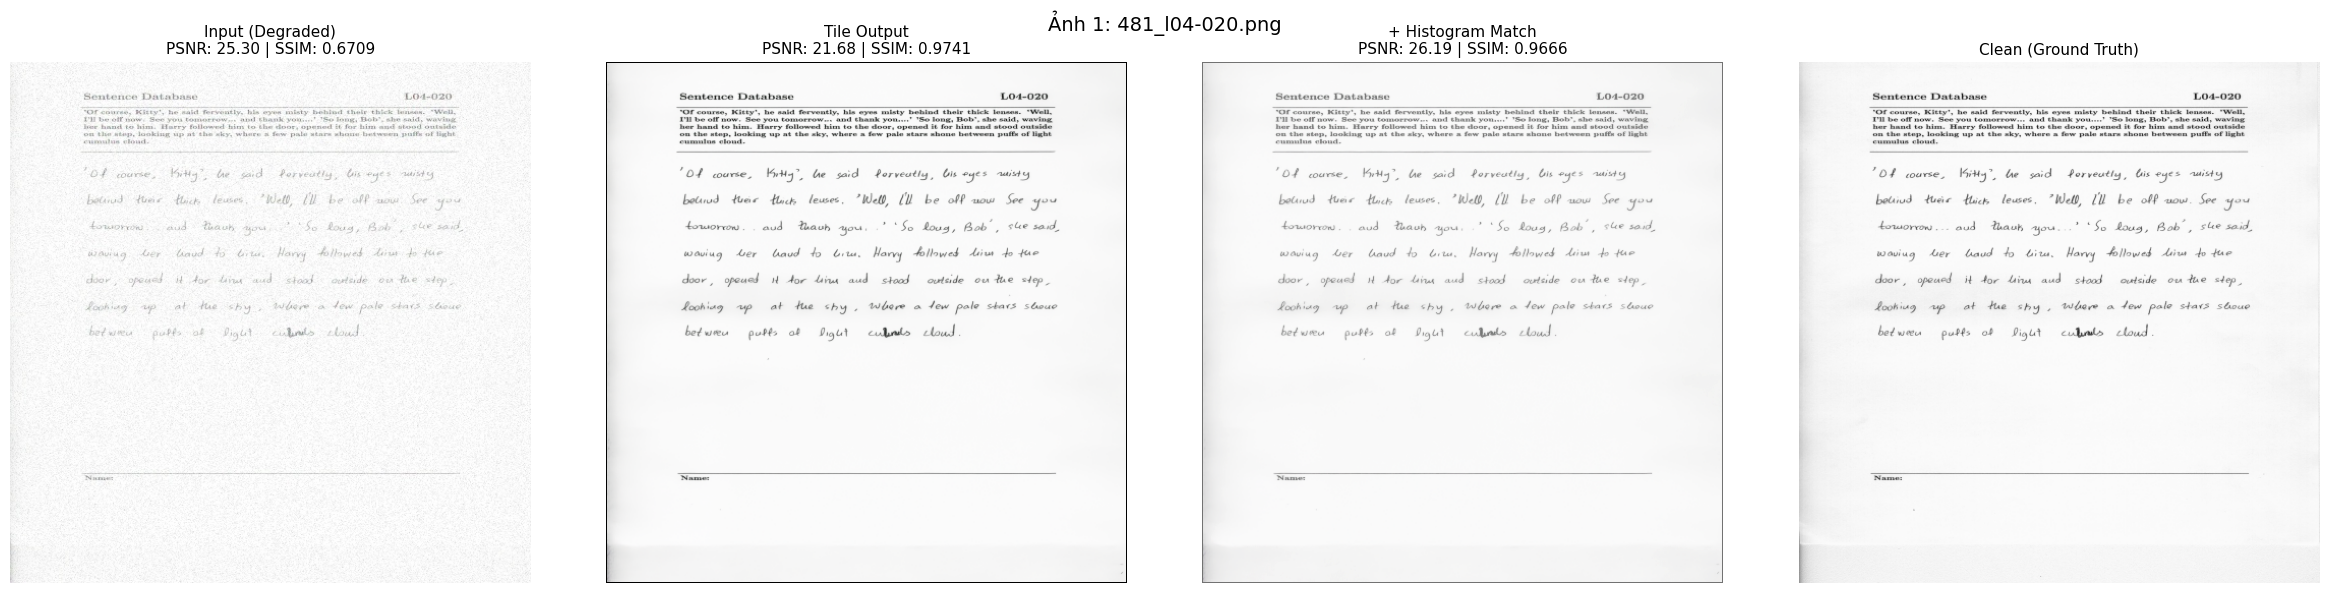


📊 Metrics:
   Input:              PSNR = 25.30 dB | SSIM = 0.6709
   Tile Output:        PSNR = 21.68 dB | SSIM = 0.9741
   + Histogram Match:  PSNR = 26.19 dB | SSIM = 0.9666
   → Cải thiện PSNR:   +4.51 dB (Histogram Match)

📸 Ảnh 2/3: 077_a06-070.png
📐 Kích thước: 512x512

🚀 Bước 1: Tile Processing...


🔄 Tiles: 100%|██████████| 25/25 [00:31<00:00,  1.25s/it]


⏱️ 31.1s

🎨 Bước 2: Histogram Matching...
⏱️ 0.0s


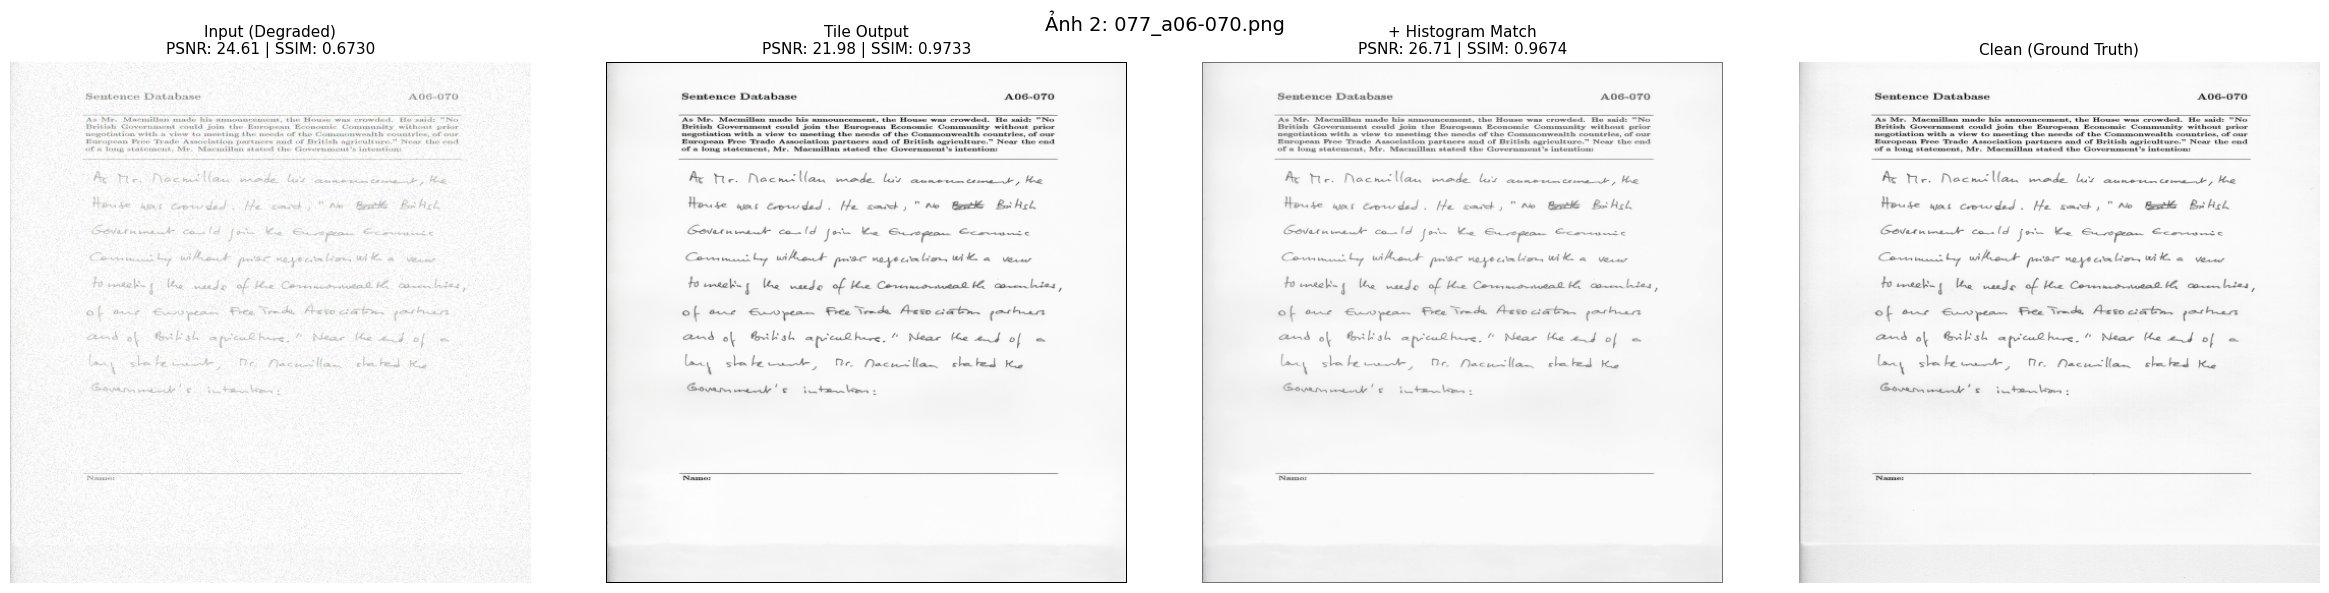


📊 Metrics:
   Input:              PSNR = 24.61 dB | SSIM = 0.6730
   Tile Output:        PSNR = 21.98 dB | SSIM = 0.9733
   + Histogram Match:  PSNR = 26.71 dB | SSIM = 0.9674
   → Cải thiện PSNR:   +4.73 dB (Histogram Match)

📸 Ảnh 3/3: 000_a05-053.png
📐 Kích thước: 512x512

🚀 Bước 1: Tile Processing...


🔄 Tiles: 100%|██████████| 25/25 [00:31<00:00,  1.26s/it]


⏱️ 31.6s

🎨 Bước 2: Histogram Matching...
⏱️ 0.0s


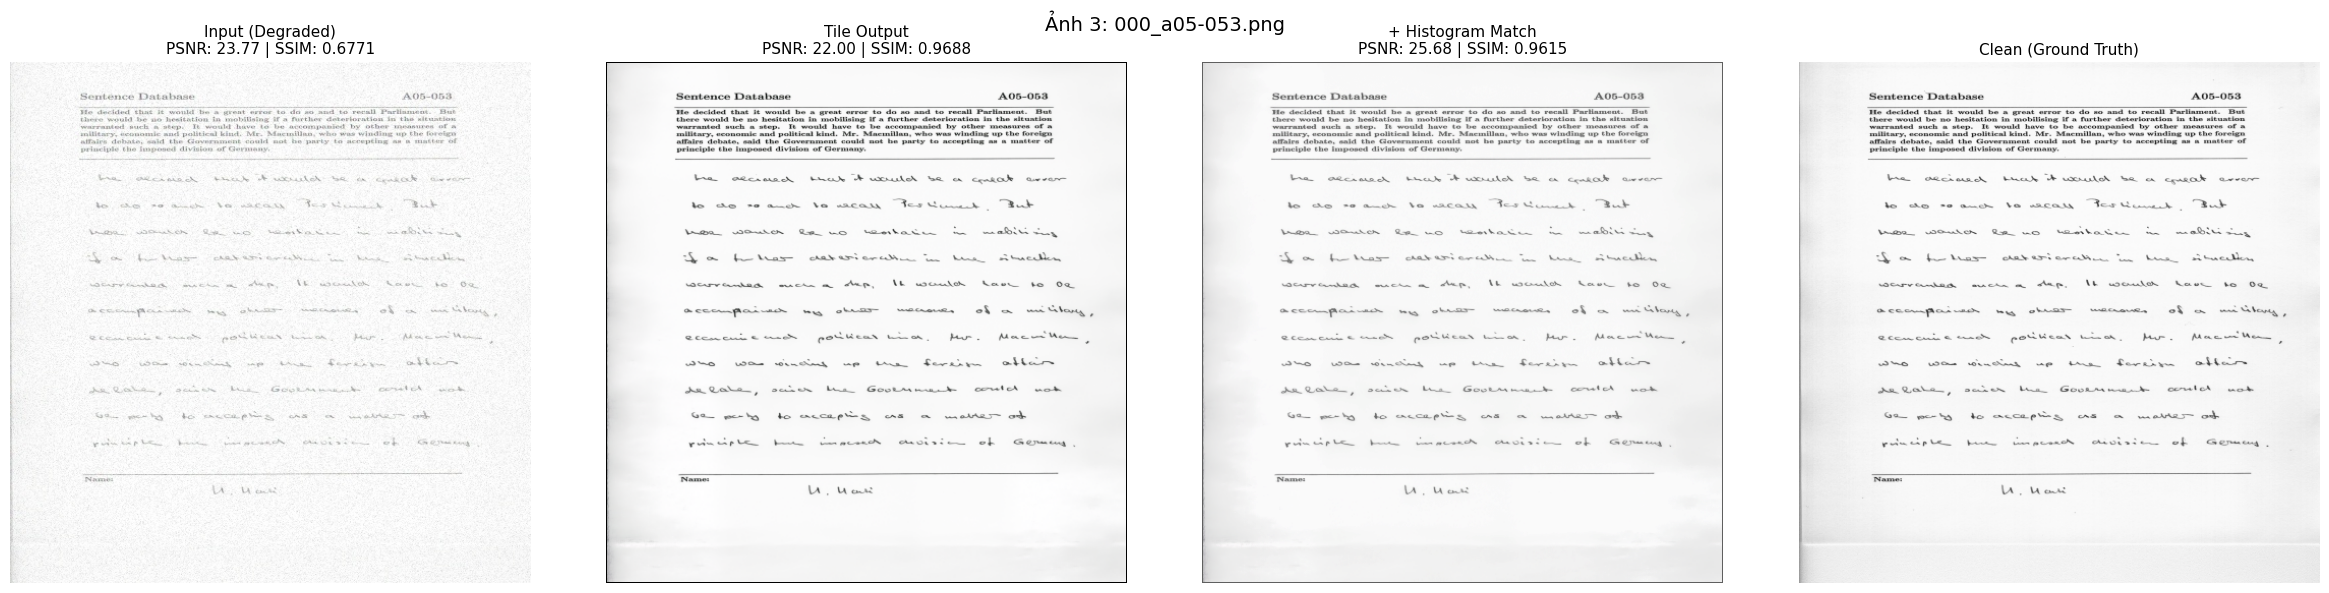


📊 Metrics:
   Input:              PSNR = 23.77 dB | SSIM = 0.6771
   Tile Output:        PSNR = 22.00 dB | SSIM = 0.9688
   + Histogram Match:  PSNR = 25.68 dB | SSIM = 0.9615
   → Cải thiện PSNR:   +3.69 dB (Histogram Match)

📊 TỔNG KẾT

Ảnh                               Input     Tile    +Hist    Cải thiện
--------------------------------------------------------------------------------
481_l04-020.png                   25.30    21.68    26.19        +4.51
077_a06-070.png                   24.61    21.98    26.71        +4.73
000_a05-053.png                   23.77    22.00    25.68        +3.69
--------------------------------------------------------------------------------
TRUNG BÌNH                        24.56    21.88    26.19        +4.31

📈 So sánh:
   Input:              PSNR = 24.56 dB
   Tile Output:        PSNR = 21.88 dB
   + Histogram Match:  PSNR = 26.19 dB
   → Histogram Match cải thiện: +4.31 dB

💾 LƯU KẾT QUẢ


🔄 Tiles: 100%|██████████| 25/25 [00:30<00:00,  1.24s/it]


  ✅ 481_l04-020


🔄 Tiles: 100%|██████████| 25/25 [00:30<00:00,  1.21s/it]


  ✅ 077_a06-070


🔄 Tiles: 100%|██████████| 25/25 [00:32<00:00,  1.28s/it]


  ✅ 000_a05-053

🎉 HOÀN THÀNH!
  adding: results/ (stored 0%)
  adding: results/000_a05-053_tile.png (deflated 4%)
  adding: results/077_a06-070_histmatch.png (deflated 4%)
  adding: results/077_a06-070_tile.png (deflated 4%)
  adding: results/481_l04-020_histmatch.png (deflated 5%)
  adding: results/481_l04-020_tile.png (deflated 6%)
  adding: results/000_a05-053_histmatch.png (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import cv2
import numpy as np
import os
import time
import glob
from tqdm import tqdm
from runpy import run_path
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.exposure import match_histograms

# ==================== CẤU HÌNH ====================
MODEL_PATH = '/content/Restormer/experiments/Document_Restoration/models/net_g_50000.pth'
DATA_ROOT = '/content/data'
TILE_SIZE = 128
TILE_OVERLAP = 32
DEG_TYPE = 'noise'
NUM_TEST = 3
# ====================================================

# ==================== 1. LOAD MODEL ====================
print("="*60)
print("📦 LOAD MODEL")
print("="*60)

MODEL_PARAMS = {
    'inp_channels': 3, 'out_channels': 3,
    'dim': 32,
    'num_blocks': [2, 4, 4, 6],
    'num_refinement_blocks': 2,
    'heads': [1, 2, 4, 8],
    'ffn_expansion_factor': 2.66,
    'bias': False,
    'LayerNorm_type': 'BiasFree',
    'dual_pixel_task': False
}

load_arch = run_path('/content/Restormer/basicsr/models/archs/restormer_arch.py')
model = load_arch['Restormer'](**MODEL_PARAMS)
device = torch.device('cpu')
model = model.to(device)
model.eval()

ckpt = torch.load(MODEL_PATH, map_location='cpu')
model.load_state_dict(ckpt['params'])
print("✅ Đã load model")


# ==================== 2. HÀM TILE PROCESSING ====================
def process_with_tiles(model, img, tile_size=128, overlap=32, device='cpu'):
    """Xử lý ảnh lớn bằng tile processing với overlap blending"""
    h, w = img.shape[:2]
    stride = tile_size - overlap

    output = np.zeros((h, w, 3), dtype=np.float32)
    weight = np.zeros((h, w), dtype=np.float32)

    n_tiles_y = max(1, (h - overlap + stride - 1) // stride)
    n_tiles_x = max(1, (w - overlap + stride - 1) // stride)
    total_tiles = n_tiles_y * n_tiles_x

    # Weight window
    wy = np.ones(tile_size, dtype=np.float32)
    wx = np.ones(tile_size, dtype=np.float32)
    for i in range(overlap):
        val = 0.5 * (1 - np.cos(np.pi * i / overlap))
        wy[i] = val
        wy[tile_size - 1 - i] = val
        wx[i] = val
        wx[tile_size - 1 - i] = val
    weight_window = np.outer(wy, wx)

    pbar = tqdm(total=total_tiles, desc="🔄 Tiles")

    for ty in range(n_tiles_y):
        for tx in range(n_tiles_x):
            y = ty * stride
            x = tx * stride

            y_end = min(y + tile_size, h)
            x_end = min(x + tile_size, w)
            y_start = max(0, y_end - tile_size)
            x_start = max(0, x_end - tile_size)

            tile = img[y_start:y_end, x_start:x_end]
            th, tw = tile.shape[:2]

            if th < tile_size or tw < tile_size:
                tile = cv2.copyMakeBorder(tile, 0, tile_size-th, 0, tile_size-tw, cv2.BORDER_REFLECT_101)

            tile_tensor = torch.from_numpy(tile).float() / 255.0
            tile_tensor = tile_tensor.permute(2, 0, 1).unsqueeze(0).to(device)

            with torch.no_grad():
                restored = model(tile_tensor)
                restored = torch.clamp(restored, 0, 1)

            restored = restored[:, :, :th, :tw]
            restored = restored.permute(0, 2, 3, 1).cpu().numpy()[0]
            restored = (restored * 255).astype(np.float32)

            w_window = weight_window[:th, :tw]
            output[y_start:y_start+th, x_start:x_start+tw] += restored * w_window[..., None]
            weight[y_start:y_start+th, x_start:x_start+tw] += w_window

            pbar.update(1)

    pbar.close()
    weight = np.maximum(weight, 1e-8)
    output = output / weight[..., None]
    output = np.clip(output, 0, 255).astype(np.uint8)

    return output


# ==================== 3. HISTOGRAM MATCHING ====================
def histogram_match(source, reference):
    """
    Điều chỉnh histogram của source cho giống reference.

    Args:
        source: Ảnh cần điều chỉnh (H, W, 3)
        reference: Ảnh tham chiếu (H, W, 3)

    Returns:
        Ảnh source đã match histogram với reference
    """
    matched = match_histograms(source, reference, channel_axis=2)
    return matched.astype(np.uint8)


# ==================== 4. TEST ====================
print("\n" + "="*60)
print("🧪 TEST TILE PROCESSING + HISTOGRAM MATCHING")
print("="*60)

clean_dir = f'{DATA_ROOT}/test/clean'
noise_dir = f'{DATA_ROOT}/test/degraded/{DEG_TYPE}'

clean_files = sorted(glob.glob(f'{clean_dir}/*'))
noise_files = sorted(glob.glob(f'{noise_dir}/*'))

print(f"📸 Test set: {len(clean_files)} ảnh")

import random
random.seed(42)
test_indices = random.sample(range(min(len(clean_files), len(noise_files))),
                             min(NUM_TEST, len(clean_files)))

results = []

for idx, i in enumerate(test_indices):
    clean_path = clean_files[i]
    noise_path = noise_files[i]
    filename = os.path.basename(clean_path)

    print(f"\n{'='*60}")
    print(f"📸 Ảnh {idx+1}/{NUM_TEST}: {filename}")
    print(f"{'='*60}")

    # Đọc ảnh
    clean = cv2.cvtColor(cv2.imread(clean_path), cv2.COLOR_BGR2RGB)
    noise = cv2.cvtColor(cv2.imread(noise_path), cv2.COLOR_BGR2RGB)

    h, w = clean.shape[:2]
    print(f"📐 Kích thước: {w}x{h}")

    # ==================== BƯỚC 1: TILE PROCESSING ====================
    print("\n🚀 Bước 1: Tile Processing...")
    start = time.time()
    output_tiled = process_with_tiles(model, noise, TILE_SIZE, TILE_OVERLAP, device)
    time_tile = time.time() - start
    print(f"⏱️ {time_tile:.1f}s")

    # ==================== BƯỚC 2: HISTOGRAM MATCHING ====================
    print("\n🎨 Bước 2: Histogram Matching...")
    start = time.time()

    # ✅ Match histogram với CLEAN (để so sánh)
    output_matched = histogram_match(output_tiled, clean)

    time_hist = time.time() - start
    print(f"⏱️ {time_hist:.1f}s")

    # ==================== 3. TÍNH METRICS ====================
    # Input vs Clean
    psnr_in = psnr(clean, noise, data_range=255)
    ssim_in = ssim(clean, noise, channel_axis=2, data_range=255)

    # Tile processing vs Clean
    psnr_tile = psnr(clean, output_tiled, data_range=255)
    ssim_tile = ssim(clean, output_tiled, channel_axis=2, data_range=255)

    # Histogram matching vs Clean
    psnr_hist = psnr(clean, output_matched, data_range=255)
    ssim_hist = ssim(clean, output_matched, channel_axis=2, data_range=255)

    results.append({
        'filename': filename,
        'psnr_in': psnr_in, 'ssim_in': ssim_in,
        'psnr_tile': psnr_tile, 'ssim_tile': ssim_tile,
        'psnr_hist': psnr_hist, 'ssim_hist': ssim_hist,
    })

    # ==================== 4. HIỂN THỊ ====================
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    axes[0].imshow(noise)
    axes[0].set_title(f'Input (Degraded)\nPSNR: {psnr_in:.2f} | SSIM: {ssim_in:.4f}', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(output_tiled)
    axes[1].set_title(f'Tile Output\nPSNR: {psnr_tile:.2f} | SSIM: {ssim_tile:.4f}', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(output_matched)
    axes[2].set_title(f'+ Histogram Match\nPSNR: {psnr_hist:.2f} | SSIM: {ssim_hist:.4f}', fontsize=11)
    axes[2].axis('off')

    axes[3].imshow(clean)
    axes[3].set_title('Clean (Ground Truth)', fontsize=11)
    axes[3].axis('off')

    plt.suptitle(f'Ảnh {idx+1}: {filename}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # In metrics
    print(f"\n📊 Metrics:")
    print(f"   Input:              PSNR = {psnr_in:.2f} dB | SSIM = {ssim_in:.4f}")
    print(f"   Tile Output:        PSNR = {psnr_tile:.2f} dB | SSIM = {ssim_tile:.4f}")
    print(f"   + Histogram Match:  PSNR = {psnr_hist:.2f} dB | SSIM = {ssim_hist:.4f}")
    print(f"   → Cải thiện PSNR:   +{psnr_hist - psnr_tile:.2f} dB (Histogram Match)")


# ==================== 5. TỔNG KẾT ====================
print("\n" + "="*60)
print("📊 TỔNG KẾT")
print("="*60)

print(f"\n{'Ảnh':<30} {'Input':>8} {'Tile':>8} {'+Hist':>8} {'Cải thiện':>12}")
print("-"*80)

for r in results:
    print(f"{r['filename']:<30} {r['psnr_in']:>8.2f} {r['psnr_tile']:>8.2f} "
          f"{r['psnr_hist']:>8.2f} {r['psnr_hist']-r['psnr_tile']:>+12.2f}")

# Trung bình
avg_in = np.mean([r['psnr_in'] for r in results])
avg_tile = np.mean([r['psnr_tile'] for r in results])
avg_hist = np.mean([r['psnr_hist'] for r in results])

print("-"*80)
print(f"{'TRUNG BÌNH':<30} {avg_in:>8.2f} {avg_tile:>8.2f} {avg_hist:>8.2f} "
      f"{avg_hist-avg_tile:>+12.2f}")

print(f"\n📈 So sánh:")
print(f"   Input:              PSNR = {avg_in:.2f} dB")
print(f"   Tile Output:        PSNR = {avg_tile:.2f} dB")
print(f"   + Histogram Match:  PSNR = {avg_hist:.2f} dB")
print(f"   → Histogram Match cải thiện: +{avg_hist - avg_tile:.2f} dB")


# ==================== 6. LƯU KẾT QUẢ ====================
print("\n" + "="*60)
print("💾 LƯU KẾT QUẢ")
print("="*60)

os.makedirs('/content/results', exist_ok=True)

for idx, i in enumerate(test_indices):
    noise_path = noise_files[i]
    clean_path = clean_files[i]
    filename = os.path.splitext(os.path.basename(noise_path))[0]

    noise = cv2.cvtColor(cv2.imread(noise_path), cv2.COLOR_BGR2RGB)
    clean = cv2.cvtColor(cv2.imread(clean_path), cv2.COLOR_BGR2RGB)

    output_tiled = process_with_tiles(model, noise, TILE_SIZE, TILE_OVERLAP, device)
    output_matched = histogram_match(output_tiled, clean)

    # Lưu
    cv2.imwrite(f'/content/results/{filename}_tile.png',
                cv2.cvtColor(output_tiled, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f'/content/results/{filename}_histmatch.png',
                cv2.cvtColor(output_matched, cv2.COLOR_RGB2BGR))
    print(f"  ✅ {filename}")

print(f"\n🎉 HOÀN THÀNH!")

# Tải về máy
from google.colab import files
!cd /content && zip -r results.zip results/
files.download('/content/results.zip')